In [3]:
# Install detectron2
import torch
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)
# Install detectron2 that matches the above pytorch version
# See https://detectron2.readthedocs.io/tutorials/install.html for instructions
!pip install git+https://github.com/facebookresearch/detectron2.git
# Use the below line to install detectron2 if the above one has an error
# !python -m pip install 'git+https://github.com/facebookresearch/detectron2.git@v0.6'

torch:  2.0 ; cuda:  cpu
  Cloning https://github.com/facebookresearch/detectron2.git to c:\users\ghost\appdata\local\temp\pip-req-build-wrnvg45f
  Resolved https://github.com/facebookresearch/detectron2.git to commit a9c0821a12ad353fb2a96f019515990d5460c5ac
Using legacy 'setup.py install' for detectron2, since package 'wheel' is not installed.
Using legacy 'setup.py install' for fvcore, since package 'wheel' is not installed.
Using legacy 'setup.py install' for antlr4-python3-runtime, since package 'wheel' is not installed.
    Running setup.py install for antlr4-python3-runtime: started
    Running setup.py install for antlr4-python3-runtime: finished with status 'done'
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0
    Uninstalling pycocotools-2.0:
      Successfully uninstalled pycocotools-2.0
    Running setup.py install for fvcore: started
    Running setup.py install for fvcore: finished with status 'done'
    Running setup.py install for de

  Running command git clone -q https://github.com/facebookresearch/detectron2.git 'C:\Users\Ghost\AppData\Local\Temp\pip-req-build-wrnvg45f'


In [4]:
# clone and install Detic
!git clone https://github.com/facebookresearch/Detic.git --recurse-submodules
%cd Detic
!pip install -r requirements.txt

Submodule path 'third_party/CenterNet2': checked out '8745e012e4dbdf560ac2f27e0b771d4907ad4aaf'
Submodule path 'third_party/Deformable-DETR': checked out '11169a60c33333af00a4849f1808023eba96a931'
d:\Datalarım\Desktop\Bitirme\object_detection\zero_shot\detic\Detic


Cloning into 'Detic'...
Submodule 'third_party/CenterNet2' (https://github.com/xingyizhou/CenterNet2.git) registered for path 'third_party/CenterNet2'
Submodule 'third_party/Deformable-DETR' (https://github.com/fundamentalvision/Deformable-DETR.git) registered for path 'third_party/Deformable-DETR'
Cloning into 'D:/Datalarım/Desktop/Bitirme/object_detection/zero_shot/detic/Detic/third_party/CenterNet2'...
Cloning into 'D:/Datalarım/Desktop/Bitirme/object_detection/zero_shot/detic/Detic/third_party/Deformable-DETR'...
d:\Datalarım\Desktop\Bitirme\object_detection\zero_shot\detic\venv\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


  Cloning https://github.com/openai/CLIP.git to c:\users\ghost\appdata\local\temp\pip-req-build-yvdhnqgy
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
    Preparing wheel metadata: started
    Preparing wheel metadata: finished with status 'error'
  Using cached pybind11-3.0.1-py3-none-any.whl (293 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
Using legacy 'setup.py install' for fasttext, since package 'wheel' is not installed.
Using legacy 'setup.py install' for clip, since package 'wheel' is not installed.
    Running setup.py install for fasttext: started
    Running setup.py install for fasttext: finished with status 'error'


  Running command git clone -q https://github.com/openai/CLIP.git 'C:\Users\Ghost\AppData\Local\Temp\pip-req-build-yvdhnqgy'
    ERROR: Command errored out with exit status 1:
     command: 'D:\Datalarım\Desktop\Bitirme\object_detection\zero_shot\detic\venv\Scripts\python.exe' 'D:\Datalarım\Desktop\Bitirme\object_detection\zero_shot\detic\venv\lib\site-packages\pip\_vendor\pep517\in_process\_in_process.py' prepare_metadata_for_build_wheel 'C:\Users\Ghost\AppData\Local\Temp\tmp_bgdz3g_'
         cwd: C:\Users\Ghost\AppData\Local\Temp\pip-install-y05qc99c\fasttext_41ca51b45d954ee1b228d7723aad09b1
    Complete output (18 lines):
    Error in sitecustomize; set PYTHONVERBOSE for traceback:
    SyntaxError: (unicode error) 'utf-8' codec can't decode byte 0xfd in position 0: invalid start byte (sitecustomize.py, line 7)
    D:\DatalarÄ±m\Desktop\Bitirme\object_detection\zero_shot\detic\venv\lib\site-packages\setuptools\dist.py:697: UserWarning: Usage of dash-separated 'description-file' will

In [ ]:
# Some basic setup:
# Setup detectron2 logger
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()

# import some common libraries
import sys
import numpy as np
import os, json, cv2, random
from google.colab.patches import cv2_imshow

# import some common detectron2 utilities
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor
from detectron2.config import get_cfg
from detectron2.utils.visualizer import Visualizer
from detectron2.data import MetadataCatalog, DatasetCatalog

# Detic libraries
sys.path.insert(0, 'third_party/CenterNet2/')
from centernet.config import add_centernet_config
from detic.config import add_detic_config
from detic.modeling.utils import reset_cls_test

In [ ]:
# Build the detector and download our pretrained weights
cfg = get_cfg()
add_centernet_config(cfg)
add_detic_config(cfg)
cfg.merge_from_file("configs/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.yaml")
cfg.MODEL.WEIGHTS = 'https://dl.fbaipublicfiles.com/detic/Detic_LCOCOI21k_CLIP_SwinB_896b32_4x_ft4x_max-size.pth'
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set threshold for this model
cfg.MODEL.ROI_BOX_HEAD.ZEROSHOT_WEIGHT_PATH = 'rand'
cfg.MODEL.ROI_HEADS.ONE_CLASS_PER_PROPOSAL = True # For better visualization purpose. Set to False for all classes.
# cfg.MODEL.DEVICE='cpu' # uncomment this to use cpu-only mode.
predictor = DefaultPredictor(cfg)

In [ ]:
# Setup the model's vocabulary using build-in datasets

BUILDIN_CLASSIFIER = {
    'lvis': 'datasets/metadata/lvis_v1_clip_a+cname.npy',
    'objects365': 'datasets/metadata/o365_clip_a+cnamefix.npy',
    'openimages': 'datasets/metadata/oid_clip_a+cname.npy',
    'coco': 'datasets/metadata/coco_clip_a+cname.npy',
}

BUILDIN_METADATA_PATH = {
    'lvis': 'lvis_v1_val',
    'objects365': 'objects365_v2_val',
    'openimages': 'oid_val_expanded',
    'coco': 'coco_2017_val',
}

vocabulary = 'lvis' # change to 'lvis', 'objects365', 'openimages', or 'coco'
metadata = MetadataCatalog.get(BUILDIN_METADATA_PATH[vocabulary])
classifier = BUILDIN_CLASSIFIER[vocabulary]
num_classes = len(metadata.thing_classes)
reset_cls_test(predictor.model, classifier, num_classes)

In [ ]:
# Download a sample image and display. Replace path here to try your own images!

im = cv2.imread(r"D:\Datalarım\Desktop\Bitirme\object_detection\zero_shot\karnıyarık.jpg")
cv2_imshow(im)

/usr/local/lib/python3.7/dist-packages/detectron2/structures/image_list.py:88: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


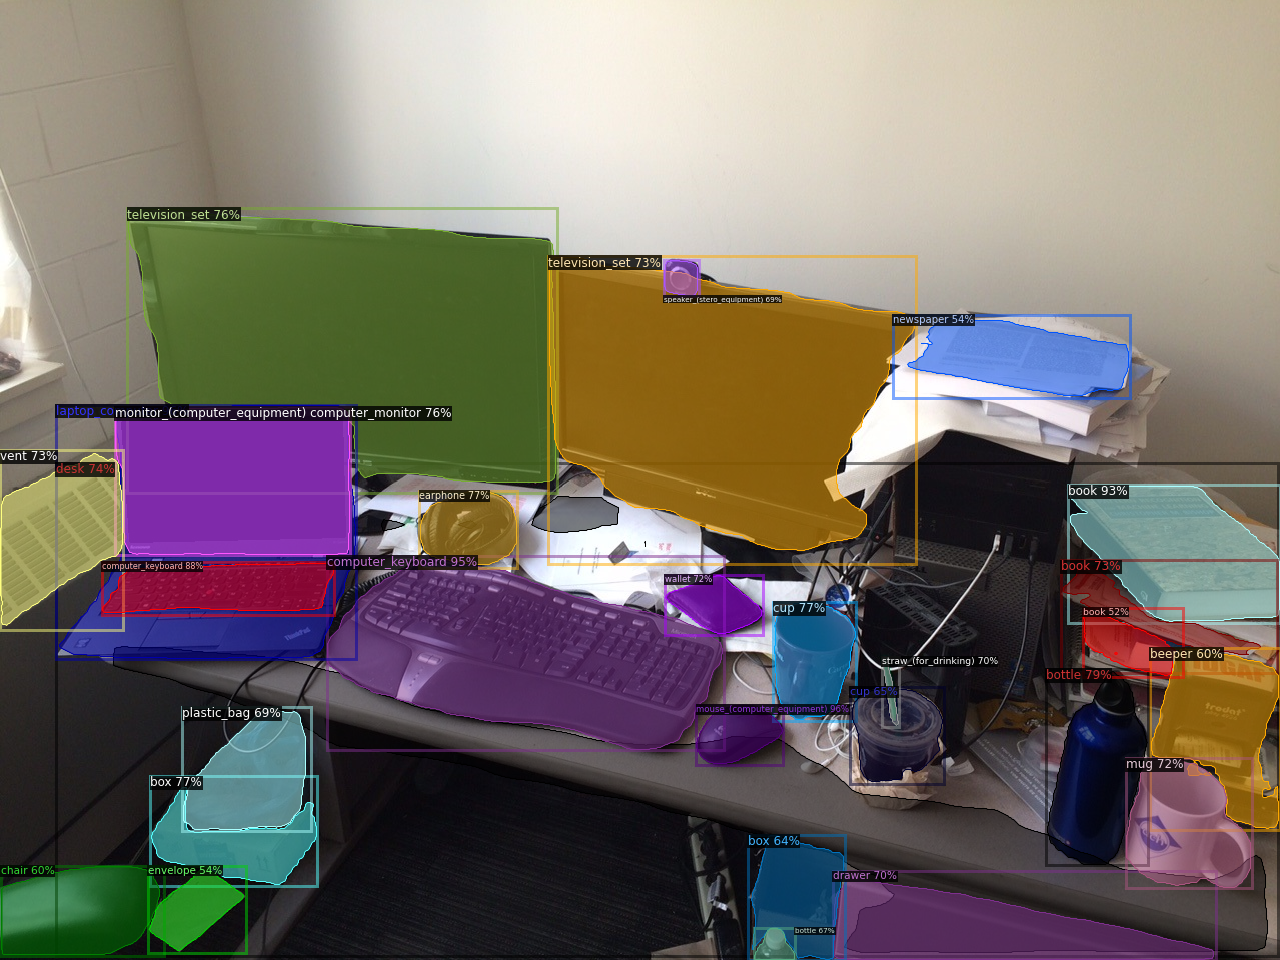

In [ ]:
# Run model and show results
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1], metadata)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])

In [ ]:
# Change the model's vocabulary to a customized one and get their word-embedding
#  using a pre-trained CLIP model.

from detic.modeling.text.text_encoder import build_text_encoder
def get_clip_embeddings(vocabulary, prompt='a '):
    text_encoder = build_text_encoder(pretrain=True)
    text_encoder.eval()
    texts = [prompt + x for x in vocabulary]
    emb = text_encoder(texts).detach().permute(1, 0).contiguous().cpu()
    return emb

vocabulary = 'custom'
metadata = MetadataCatalog.get("__unused")
metadata.thing_classes = ["parsley", "pizza", "ramen", "egg", "cucumber", "tomato", "onion", "garlic", "meat", "rice", "potato", "karnıyarık", "yoghurt"]
classifier = get_clip_embeddings(metadata.thing_classes)
num_classes = len(metadata.thing_classes)
reset_cls_test(predictor.model, classifier, num_classes)
# Reset visualization threshold
output_score_threshold = 0.3
for cascade_stages in range(len(predictor.model.roi_heads.box_predictor)):
    predictor.model.roi_heads.box_predictor[cascade_stages].test_score_thresh = output_score_threshold

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 83.6MiB/s]


Loading pretrained CLIP


/usr/local/lib/python3.7/dist-packages/detectron2/structures/image_list.py:88: UserWarning: __floordiv__ is deprecated, and its behavior will change in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values. To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor').
  max_size = (max_size + (stride - 1)) // stride * stride


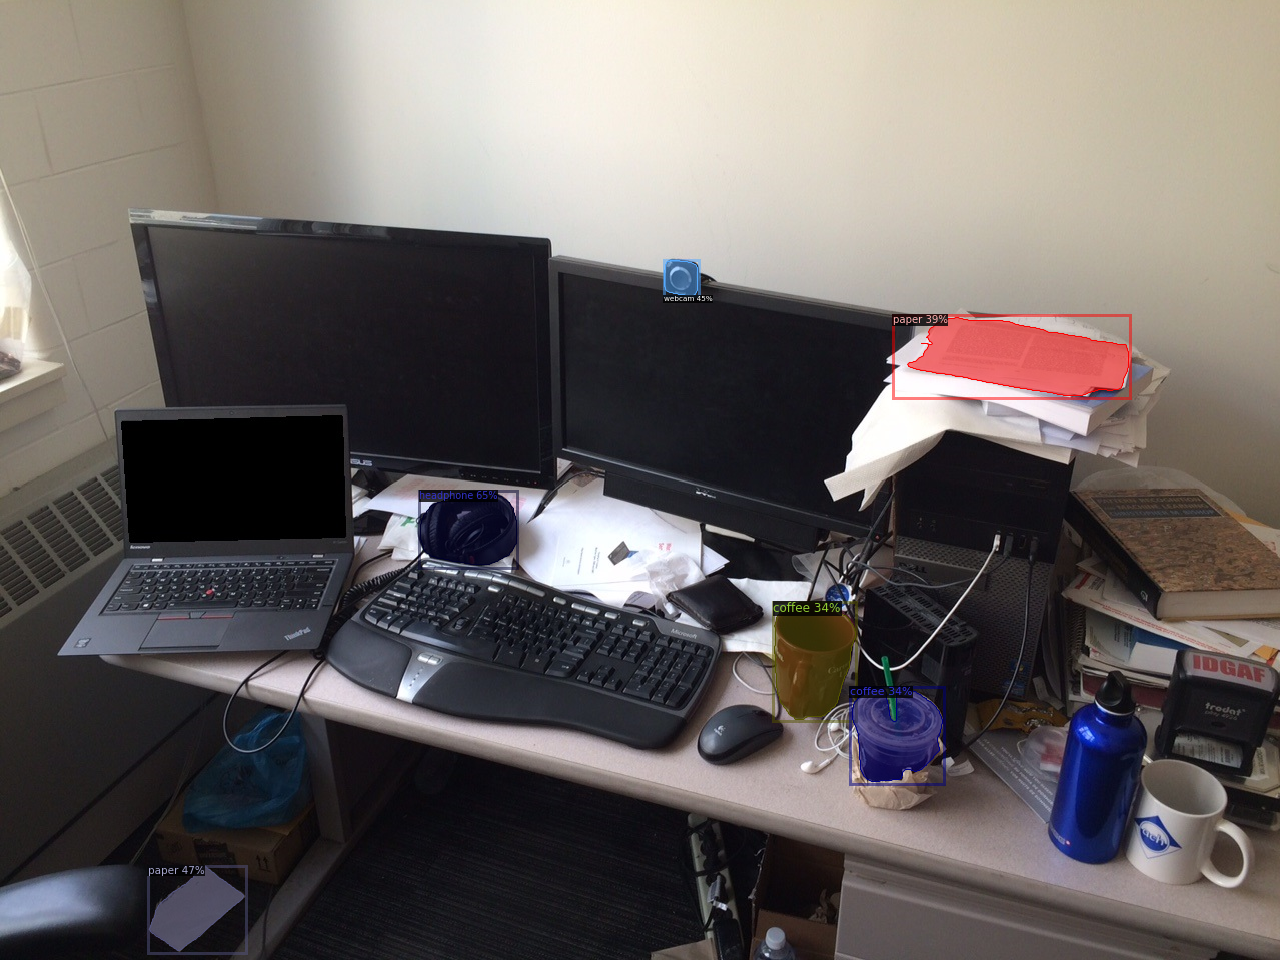

In [ ]:
# Run model and show results
outputs = predictor(im)
v = Visualizer(im[:, :, ::-1], metadata)
out = v.draw_instance_predictions(outputs["instances"].to("cpu"))
cv2_imshow(out.get_image()[:, :, ::-1])

In [ ]:
# look at the outputs.
# See https://detectron2.readthedocs.io/tutorials/models.html#model-output-format for specification
print(outputs["instances"].pred_classes) # class index
print([metadata.thing_classes[x] for x in outputs["instances"].pred_classes.cpu().tolist()]) # class names
print(outputs["instances"].scores)
print(outputs["instances"].pred_boxes)

tensor([0, 2, 1, 2, 3, 3], device='cuda:0')
['headphone', 'paper', 'webcam', 'paper', 'coffee', 'coffee']
tensor([0.6491, 0.4727, 0.4451, 0.3891, 0.3375, 0.3370], device='cuda:0')
Boxes(tensor([[ 419.1836,  491.0833,  517.4153,  567.7355],
        [ 147.8862,  865.7650,  245.6065,  952.5587],
        [ 663.5049,  259.6931,  698.9725,  296.0034],
        [ 892.8219,  314.8461, 1129.9359,  398.4209],
        [ 850.0912,  686.8865,  943.6356,  783.7984],
        [ 773.4060,  602.2183,  856.4294,  720.5630]], device='cuda:0'))
